In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer
import numpy as np

df = pd.read_csv('ashrae_db2.01.csv')

print(df.head())

target_columns = [
    'Age', 'Sex', 'Subject«s height (cm)', 'Subject«s weight (kg)', 
    'Air temperature (C)', 'Relative humidity (%)', 'Thermal comfort'
]
df_subset = df[target_columns].copy()

for col in df_subset.columns:
    if col != 'Sex':
        df_subset[col] = pd.to_numeric(df_subset[col], errors='coerce')
df_subset['Sex'] = df_subset['Sex'].map({'Male': 0, 'Female': 1})

# We only drop if these specific columns are NA
df_filtered = df_subset.dropna(subset=['Air temperature (C)', 'Relative humidity (%)', 'Thermal comfort'])

print(f"Rows after dropping critical NAs: {len(df_filtered)}")

# The imputer will only fill the remaining gaps in the columns we kept
imputer = SimpleImputer(strategy='median')
df_final = pd.DataFrame(imputer.fit_transform(df_filtered), columns=df_filtered.columns)

df_final['Comfort_Level'] = pd.cut(df_final['Thermal comfort'], 
                                   bins=8, 
                                   labels=[1, 2, 3, 4, 5, 6, 7, 8]).astype(int)

                              Publication (Citation) Data contributor    Year  \
0  Kwok, Alison G., and Chungyoon Chun. "Thermal ...      Kwok Alison  2000.0   
1  Kwok, Alison G., and Chungyoon Chun. "Thermal ...      Kwok Alison  2000.0   
2  Kwok, Alison G., and Chungyoon Chun. "Thermal ...      Kwok Alison  2000.0   
3  Kwok, Alison G., and Chungyoon Chun. "Thermal ...      Kwok Alison  2000.0   
4  Kwok, Alison G., and Chungyoon Chun. "Thermal ...      Kwok Alison  2000.0   

   Season Koppen climate classification            Climate   City Country  \
0  Summer                           Cfa  Humid subtropical  Tokyo   Japan   
1  Summer                           Cfa  Humid subtropical  Tokyo   Japan   
2  Summer                           Cfa  Humid subtropical  Tokyo   Japan   
3  Summer                           Cfa  Humid subtropical  Tokyo   Japan   
4  Summer                           Cfa  Humid subtropical  Tokyo   Japan   

  Building type Cooling startegy_building level  .

C:\Users\48888\AppData\Local\Temp\ipykernel_2348\1831928377.py:5: DtypeWarning: Columns (0: Cooling startegy_operation mode for MM buildings, 1: Heating strategy_building level, 2: Sex, 3: Air movement preference, 4: Thermal comfort, 5: Ta_m (F), 6: Humidity preference) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('ashrae_db2.01.csv')


In [ ]:
def normalize_viking_hybrid(df_to_fix):
    """
    Tuned version: Smoothes the distribution but keeps hard boundaries 
    for extremes to ensure logic tests pass.
    """
    df_aug = df_to_fix.copy()
    
    df_aug['hardship'] = abs(df_aug['Air temperature (C)'] - 22) * 1.5
    df_aug['hardship'] += np.random.normal(0, 0.4, size=len(df_aug)) # Tiny jitter
    
    df_aug = df_aug.sort_values(by='hardship', ascending=True)
    num_samples = len(df_aug)
    
    for i in range(num_samples):
        rank_percent = i / num_samples
        # Map to 8-1 range (Comfortable to Extreme)
        equalized_level = int(8 - (rank_percent * 7))
        
        if np.random.rand() > 0.15:
            df_aug.iloc[i, df_aug.columns.get_loc('Comfort_Level')] = equalized_level

    # Freezing Fjord Fix: Temperatures under 12C cannot be comfortable
    df_aug.loc[df_aug['Air temperature (C)'] < 12, 'Comfort_Level'] = \
        df_aug['Comfort_Level'].apply(lambda x: min(x, 2))
        
    # Sweaty Drakkar Fix: Temperatures over 32C cannot be high comfort
    df_aug.loc[df_aug['Air temperature (C)'] > 32, 'Comfort_Level'] = \
        df_aug['Comfort_Level'].apply(lambda x: min(x, 3))
        
    # Longhouse Anchor: Ensure 22C area stays high
    df_aug.loc[(df_aug['Air temperature (C)'].between(21, 23)) & 
               (df_aug['Relative humidity (%)'].between(40, 50)), 'Comfort_Level'] = \
        df_aug['Comfort_Level'].apply(lambda x: max(x, 7))

    # Shuffle and return
    return df_aug.drop(columns=['hardship']).sample(frac=1).reset_index(drop=True)

In [ ]:
def generate_smart_bus_data(base_df):
    df = base_df.copy()
    n = len(df)
    
    # CRITICAL FIX: Convert Comfort_Level to float so we can do math like -0.5
    df['Comfort_Level'] = df['Comfort_Level'].astype(float)

    df['Density'] = np.random.uniform(0, 1, n)
    #df['Light'] = np.random.uniform(0, 1000, n)
    df['Pressure'] = 1013 + np.random.normal(0, 5, n)

    # Density penalty
    df.loc[df['Density'] > 0.7, 'Comfort_Level'] -= 2
    df.loc[df['Density'] > 0.9, 'Comfort_Level'] -= 1
    
    # Light penalty
    #mask_light_bad = (df['Light'] < 100) | (df['Light'] > 800)
    #df.loc[mask_light_bad, 'Comfort_Level'] -= 1
    
    # Pressure penalty (The 0.5 that caused the error)
    mask_pressure_stress = (df['Pressure'] < 1000) | (df['Pressure'] > 1025)
    df.loc[mask_pressure_stress, 'Comfort_Level'] -= 0.5

    # Round back to whole numbers and convert back to int
    df['Comfort_Level'] = df['Comfort_Level'].round().clip(1, 8).astype(int)
    
    return df

In [26]:
unique_ratings = sorted(df_final['Thermal comfort'].unique())
after_conversion = sorted(df_final['Comfort_Level'].unique())

print(f"Unique ratings found (Imputed): {unique_ratings[:10]}...") # Printing first 10 for brevity
print(f"Min Rating: {min(unique_ratings)}, Max Rating: {max(unique_ratings)}")
print(f"Post conversion (8 Classes): {after_conversion}")

Unique ratings found (Imputed): [np.float64(0.9), np.float64(1.0), np.float64(1.3), np.float64(1.5), np.float64(1.7), np.float64(2.0), np.float64(2.2), np.float64(2.3), np.float64(2.4), np.float64(2.5)]...
Min Rating: 0.9, Max Rating: 6.0
Post conversion (8 Classes): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [ ]:
def smith_pseudo_data(df, target_class, goal_samples):
    current_samples = df[df['Comfort_Level'] == target_class]
    num_to_generate = goal_samples - len(current_samples)
    
    if num_to_generate <= 0:
        return pd.DataFrame()

    clones = current_samples.sample(num_to_generate, replace=True)
    
    # Existing noise
    clones['Air temperature (C)'] += np.random.uniform(-0.5, 0.5, size=num_to_generate)
    clones['Relative humidity (%)'] += np.random.uniform(-2.0, 2.0, size=num_to_generate)
    clones['Age'] += np.random.randint(-1, 2, size=num_to_generate)
    
    # Density varies by +/- 5%, Light by +/- 20 Lux, Pressure by +/- 1 hPa
    clones['Density'] = (clones['Density'] + np.random.uniform(-0.05, 0.05, size=num_to_generate)).clip(0, 1)
    #clones['Light'] = (clones['Light'] + np.random.uniform(-20, 20, size=num_to_generate)).clip(0, 1000)
    clones['Pressure'] += np.random.uniform(-1, 1, size=num_to_generate)
    
    return clones

# We fix the labels on the original small dataset before cloning
print("Normalizing base data logic...")
df_viking_base = normalize_viking_hybrid(df_final)

# This function now handles the float conversion to avoid the Error
df_viking_smart = generate_smart_bus_data(df_viking_base)

# Augment to 6000 samples per class
target_count = 7000
new_rows_list = []
for level in range(1, 9):
    extra_data = smith_pseudo_data(df_viking_smart, level, target_count)
    new_rows_list.append(extra_data)

# Final Merge
df_augmented = pd.concat([df_viking_smart] + new_rows_list).reset_index(drop=True)

print("Success! Dataset is now 'Smart'.")
print(df_augmented['Comfort_Level'].value_counts().sort_index())

print(f"\nFinal Dataset Size: {len(df_augmented)}")
print("Final Distribution (Should be a perfect plateau):")
print(df_augmented['Comfort_Level'].value_counts().sort_index())

print(f"\nNew Dataset Size: {len(df_augmented)}")
print(df_augmented['Comfort_Level'].value_counts().sort_index())

Normalizing base data logic...
Success! Dataset is now 'Smart'.
Comfort_Level
1    7000
2    7000
3    7000
4    7000
5    7000
6    7000
7    7000
8    7000
Name: count, dtype: int64

Final Dataset Size: 56000
Final Distribution (Should be a perfect plateau):
Comfort_Level
1    7000
2    7000
3    7000
4    7000
5    7000
6    7000
7    7000
8    7000
Name: count, dtype: int64

New Dataset Size: 56000
Comfort_Level
1    7000
2    7000
3    7000
4    7000
5    7000
6    7000
7    7000
8    7000
Name: count, dtype: int64


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = df_augmented.drop(['Thermal comfort', 'Comfort_Level'], axis=1)
y = df_augmented['Comfort_Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(
    n_estimators=260, 
    max_depth=22, 
    min_samples_leaf=5, 
    random_state=42, 
    class_weight="balanced"
)
clf.fit(X_train, y_train)

#joblib.dump(clf, 'viking_comfort_model.pkl')
#print(f"Model trained on {len(df_final)} rows and saved as 'viking_comfort_model.pkl'")

def run_viking_tests(model):
    print("\n" + "="*40)
    print("      VIKING COMFORT LOGIC TESTS")
    print("="*40)
    
    # Format: [Age, Sex, Height, Weight, Temp, Humidity, Density, Light*, Pressure]
    scenarios = {
        "Ideal Longhouse": [[25, 0, 180, 85, 22, 45, 0.2, 1013]],
        "Sweaty Drakkar":  [[25, 0, 180, 85, 33, 80, 0.8, 1020]],
        "Freezing Fjord":  [[25, 1, 165, 60, 10, 25, 0.1, 990]],
        "Average User":    [[35, 1, 170, 70, 24, 50, 0.55, 1005]]
    }
    
    for name, data in scenarios.items():
        pred = model.predict(data)[0]
        probs = model.predict_proba(data)[0]
        confidence = np.max(probs) * 100
        print(f"{name:16} | Predicted: {pred}/8 | Confidence: {confidence:.1f}%")

run_viking_tests(clf)

importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- FEATURE IMPORTANCE RANKING ---")
print(importances)


      VIKING COMFORT LOGIC TESTS
Ideal Longhouse  | Predicted: 7/8 | Confidence: 31.4%
Sweaty Drakkar   | Predicted: 1/8 | Confidence: 77.9%
Freezing Fjord   | Predicted: 2/8 | Confidence: 30.2%
Average User     | Predicted: 5/8 | Confidence: 31.5%

--- FEATURE IMPORTANCE RANKING ---
                 Feature  Importance
4    Air temperature (C)    0.470706
6                Density    0.180800
5  Relative humidity (%)    0.102671
7               Pressure    0.087007
0                    Age    0.059031
3  Subject«s weight (kg)    0.048582
2  Subject«s height (cm)    0.039880
1                    Sex    0.011322


c:\Users\48888\Desktop\UJ\ZEnvironment\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\48888\Desktop\UJ\ZEnvironment\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\48888\Desktop\UJ\ZEnvironment\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\48888\Desktop\UJ\ZEnvironment\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\48888\Desktop\UJ\ZEnvironment\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does

Overall Model Accuracy: 70.28%

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           1       0.77      0.93      0.84      1394
           2       0.74      0.74      0.74      1402
           3       0.69      0.70      0.69      1440
           4       0.62      0.62      0.62      1388
           5       0.60      0.55      0.57      1417
           6       0.63      0.64      0.63      1401
           7       0.70      0.69      0.70      1328
           8       0.88      0.75      0.81      1430

    accuracy                           0.70     11200
   macro avg       0.70      0.70      0.70     11200
weighted avg       0.70      0.70      0.70     11200



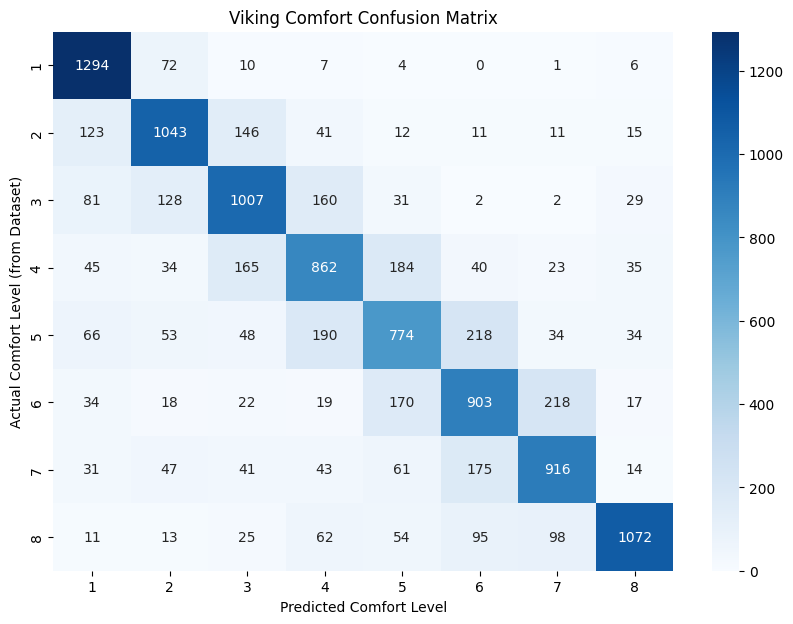

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Model Accuracy: {accuracy * 100:.2f}%")

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[1,2,3,4,5,6,7,8], 
            yticklabels=[1,2,3,4,5,6,7,8])
plt.xlabel('Predicted Comfort Level')
plt.ylabel('Actual Comfort Level (from Dataset)')
plt.title('Viking Comfort Confusion Matrix')
plt.show()

In [30]:
from sklearn.model_selection import cross_val_score

# Run the model 5 different times on 5 different subsets of the data
#scores = cross_val_score(clf, X, y, cv=5)

#print("\n--- CROSS-VALIDATION (5-FOLD) ---")
#print(f"Average Accuracy: {scores.mean() * 100:.2f}%")
#print(f"Stability (Standard Deviation): {scores.std() * 100:.2f}%")

In [ ]:
import onnx
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# 'X.shape[1]' is the number of features (8 in your case)
# 'None' allows for a variable batch size (predicting 1 or 100 people at once)
initial_type = [('float_input', FloatTensorType([None, X.shape[1]]))]

# We set target_opset=12 or higher for better compatibility
onx = convert_sklearn(clf, initial_types=initial_type, target_opset=12)

# Save to file
with open("viking_comfort_model.onnx", "wb") as f:
    f.write(onx.SerializeToString())

print("Viking Model successfully exported to 'viking_comfort_model.onnx'!")

Viking Model successfully exported to 'viking_comfort_model.onnx'!


In [32]:
import onnxruntime as rt

# Load the ONNX model
sess = rt.InferenceSession("viking_comfort_model.onnx")

# Create a test input (matching your Average User test)
# [Age, Sex, Height, Weight, Temp, Humidity, Density, Pressure]
test_input = np.array([[35, 1, 170, 70, 24, 50, 0.55, 1005]], dtype=np.float32)

# Run the inference
input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name
pred_onnx = sess.run([label_name], {input_name: test_input})[0]

print(f"ONNX Predicted Comfort Level: {pred_onnx[0]}")
print(f"Model Predicted Comfort Level: {clf.predict([[35, 1, 170, 70, 24, 50, 0.55, 1005]])}")


ONNX Predicted Comfort Level: 5
Model Predicted Comfort Level: [5]


c:\Users\48888\Desktop\UJ\ZEnvironment\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [33]:
print(sess.run([label_name], {input_name: [[35, 1, 170, 70, 24, 50, 0.55, 1005]]})[0][0])

5
